In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive

In [ ]:
path = '/content/drive/MyDrive/Data AVD/tourism_dataset_5000 (2).csv'

In [ ]:
df = pd.read_csv(path)

In [ ]:
df.head(30)

,Tourist ID,Age,Interests,Preferred Tour Duration,Accessibility,Site Name,Sites Visited,Tour Duration,Route ID,Tourist Rating,System Response Time,Recommendation Accuracy,VR Experience Quality,Satisfaction
0,1,48,"['Architecture', 'Art', 'History']",5,False,Eiffel Tower,"['Eiffel Tower', 'Great Wall of China', 'Taj M...",7,1000,1.6,3.73,97,4.5,3
1,2,37,"['Cultural', 'Nature']",6,False,Colosseum,['Great Wall of China'],1,2000,2.6,2.89,90,4.5,3
2,3,43,"['History', 'Art', 'Architecture']",6,True,Machu Picchu,['Eiffel Tower'],2,3000,1.7,2.22,94,4.7,3
3,4,46,"['Cultural', 'Art', 'Architecture']",8,False,Colosseum,"['Machu Picchu', 'Taj Mahal']",5,4000,2.0,2.34,92,4.7,3
4,5,53,"['Architecture', 'Art']",5,True,Colosseum,"['Machu Picchu', 'Taj Mahal', 'Great Wall of C...",7,5000,3.7,2.00,96,4.8,4
5,6,50,"['Architecture', 'History', 'Cultural']",4,False,Machu Picchu,"['Great Wall of China', 'Eiffel Tower', 'Colos...",4,6000,2.2,3.74,99,4.5,3
6,7,61,"['Architecture', 'History']",7,False,Eiffel Tower,"['Eiffel Tower', 'Colosseum', 'Taj Mahal']",6,7000,4.1,4.66,93,4.5,4
7,8,23,"['Cultural', 'Architecture']",5,False,Eiffel Tower,['Colosseum'],2,8000,2.8,4.84,91,4.9,3
8,9,34,"['Cultural', 'Art']",5,True,Colosseum,"['Great Wall of China', 'Eiffel Tower', 'Colos...",6,9000,4.0,1.54,95,4.4,4
9,10,61,"['Nature', 'Architecture']",5,False,Colosseum,"['Colosseum', 'Taj Mahal', 'Machu Picchu']",6,10000,3.8,3.59,95,4.7,4


Business Understanding

Dataset ini bertujuan untuk membedah apa yang membuat wisatawan berada di level "puas" atau "cukup" agar pengelola bisa mendongkrak pengalaman mereka menjadi "sangat puas". Dengan menganalisis data rute, durasi, dan penggunaan VR, tujuannya adalah menemukan titik lemah yang masih dianggap biasa saja oleh pengunjung dan memperbaikinya agar layanan wisata di situs bersejarah jadi lebih personal dan berkesan.

1. Business Objective

    Tujuan dari proyek ini adalah meningkatkan kualitas layanan wisata dari sistem rekomendasi supaya wisatawan bisa merasa lebih puas. Dari insight yang ada, kebanyakan wisatawan hanya merasa “cukup puas”, artinya sistem sudah berjalan, tapi belum bisa bikin pengalaman wisata terasa maksimal. Kalau kepuasan wisatawan bisa ditingkatkan, maka peluang wisatawan untuk pakai layanan lagi juga lebih besar, dan citra layanan wisata jadi lebih baik.

2. Assess Situation

    Saat ini sistem punya data yang cukup lengkap tentang wisatawan, seperti minat, durasi tur, rating, kualitas VR, akurasi rekomendasi, dan response time. Tapi hasilnya menunjukkan kepuasan wisatawan masih dominan di level “cukup”. Ini bisa jadi karena rekomendasinya belum sesuai harapan, sistemnya kurang cepat, atau pengalaman VR-nya belum konsisten. Kalau ini dibiarkan, wisatawan bisa bosan dan memilih layanan lain yang lebih memuaskan.


3. Analytic Goals Project Plan

    Tujuan analisisnya adalah mencari tahu faktor apa yang paling bikin wisatawan belum sampai level “sangat puas”. Dari data kita ingin melihat apakah kepuasan dipengaruhi oleh akurasi rekomendasi, response time, kualitas VR, atau faktor lain. Selain itu analisis ini juga bisa dipakai untuk membuat model prediksi kepuasan, supaya sistem bisa tahu wisatawan mana yang berpotensi kurang puas dan bisa diperbaiki dari awal Setelah itu data dibersihkan dan disiapkan supaya gampang dianalisis. Lalu dilakukan analisis hubungan antara kepuasan dengan variabel lain seperti akurasi rekomendasi, kualitas VR, dan response time. Setelah pola ditemukan, dibuat model prediksi kepuasan dan dievaluasi hasilnya dan Terakhir dibuatlah rekomendasi perbaikan sistem supaya kepuasan wisatawan bisa meningkat

#**Check Point 2**

#**Deskripsi Data**

## Informasi lanjutan

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Tourist ID               5000 non-null   int64  
 1   Age                      5000 non-null   int64  
 2   Interests                5000 non-null   object 
 3   Preferred Tour Duration  5000 non-null   int64  
 4   Accessibility            5000 non-null   bool   
 5   Site Name                5000 non-null   object 
 6   Sites Visited            5000 non-null   object 
 7   Tour Duration            5000 non-null   int64  
 8   Route ID                 5000 non-null   int64  
 9   Tourist Rating           5000 non-null   float64
 10  System Response Time     5000 non-null   float64
 11  Recommendation Accuracy  5000 non-null   int64  
 12  VR Experience Quality    5000 non-null   float64
 13  Satisfaction             5000 non-null   int64  
dtypes: bool(1), float64(3), 

Tourist ID:
Jumlah baris: 5000
Tipe data: int64
Deskripsi: ID unik setiap wisatawan

Age:
Jumlah baris: 5000
Tipe data: int64
Deskripsi: Usia wisatawan

Interests:
Jumlah baris: 5000
Tipe data: object
Deskripsi: Minat atau preferensi wisatawan terhadap jenis wisata tertentu

Preferred Tour Duration:
Jumlah baris: 5000
Tipe data: int64
Deskripsi: Durasi tur yang diinginkan oleh wisatawan

Accessibility:
Jumlah baris: 5000
Tipe data: bool
Deskripsi: Kebutuhan aksesibilitas khusus (True/False)

Site Name:
Jumlah baris: 5000
Tipe data: object
Deskripsi: Nama destinasi wisata yang direkomendasikan atau dikunjungi

Sites Visited:
Jumlah baris: 5000
Tipe data: object
Deskripsi: Daftar lokasi wisata yang telah dikunjungi

Tour Duration:
Jumlah baris: 5000
Tipe data: int64
Deskripsi: Durasi tur aktual yang dijalani wisatawan

Route ID:
Jumlah baris: 5000
Tipe data: int64
Deskripsi: ID rute perjalanan wisata

Tourist Rating:
Jumlah baris: 5000
Tipe data: float64
Deskripsi: Rating yang diberikan wisatawan terhadap pengalaman wisata

System Response Time:
Jumlah baris: 5000
Tipe data: float64
Deskripsi: Waktu respon sistem dalam memberikan rekomendasi (dalam satuan tertentu)

Recommendation Accuracy:
Jumlah baris: 5000
Tipe data: int64
Deskripsi: Tingkat akurasi sistem dalam memberikan rekomendasi

VR Experience Quality:
Jumlah baris: 5000
Tipe data: float64
Deskripsi: Kualitas pengalaman Virtual Reality yang dirasakan wisatawan

Satisfaction:
Jumlah baris: 5000
Tipe data: int64
Deskripsi: Tingkat kepuasan wisatawan terhadap keseluruhan pengalaman wisata

### **Informasi Statistik Deskriptif**

In [ ]:
df.describe(include='all')

,Tourist ID,Age,Interests,Preferred Tour Duration,Accessibility,Site Name,Sites Visited,Tour Duration,Route ID,Tourist Rating,System Response Time,Recommendation Accuracy,VR Experience Quality,Satisfaction
count,5000.000000,5000.000000,5000,5000.00000,5000,5000,5000,5000.00000,5.000000e+03,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
unique,NaN,NaN,85,NaN,2,5,85,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,['Art'],NaN,False,Great Wall of China,['Eiffel Tower'],NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,353,NaN,2531,1013,348,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,2500.500000,43.886000,NaN,5.52280,NaN,NaN,NaN,3.97720,2.500500e+06,3.002740,3.238802,92.492200,4.493160,3.534200
std,1443.520003,15.268858,NaN,1.71186,NaN,NaN,NaN,1.99967,1.443520e+06,1.164353,1.016123,4.616081,0.290596,0.736029
min,1.000000,18.000000,NaN,3.00000,NaN,NaN,NaN,1.00000,1.000000e+03,1.000000,1.500000,85.000000,4.000000,3.000000
25%,1250.750000,30.000000,NaN,4.00000,NaN,NaN,NaN,2.00000,1.250750e+06,2.000000,2.360000,88.000000,4.200000,3.000000
50%,2500.500000,44.000000,NaN,6.00000,NaN,NaN,NaN,4.00000,2.500500e+06,3.000000,3.230000,92.000000,4.500000,3.000000
75%,3750.250000,57.000000,NaN,7.00000,NaN,NaN,NaN,5.00000,3.750250e+06,4.000000,4.130000,97.000000,4.700000,4.000000


1. Count (Kelengkapan Data)

Berdasarkan data, total baris adalah 5.000. Maka dapat disimpulkan:

Tidak ada data yang hilang pada setiap kolom (seluruh kolom berisi 5.000 data lengkap).

Kesimpulan: Seluruh kolom tidak mengandung missing values, sehingga dataset sudah lengkap dan siap digunakan untuk analisis lebih lanjut.

2. Mean vs Median (Distribusi Data)
* Kolom Tourist Id

Mean = 2500,5

Median = 2500,5 – Nilai rata-rata sama dengan median

* Kolom Preferred Tour Duration

Mean = 5,52

Median = 6,00 – Nilai rata-rata sedikit lebih rendah dari median

Perbedaan kecil ini menunjukkan distribusi durasi tur yang diinginkan relatif stabil dan tidak dipengaruhi outlier ekstrem.

* Kolom Age

Mean = 43,89

Median = 44,00 – Rata-rata hampir sama dengan median

Ini menandakan distribusi usia wisatawan cukup merata tanpa perbedaan ekstrem.

* Kolom Tour Duration

Mean = 3,98

Median = 4,00 – Perbedaan sangat kecil antara mean dan median

Menunjukkan durasi tur aktual cukup seimbang dan tidak condong ke salah satu sisi.

* Kolom Tourist Rating

Mean = 3,027

Median = 3,00 – Nilai rata-rata lebih tinggi sedikit dari median

Distribusi rating wisatawan tergolong simetris dan stabil.

* Kolom Route ID

Mean = 2,500,000

Median = 2,500,000 – Nilai rata-rata sama dengan median

* Tourist Rating

Mean = 3,00

Median = 3,00 – Nilai rata-rata sama dengan median

* Kolom Recommendation Accuracy

Mean = 92,49

Median = 92,00 – Perbedaan sangat kecil

Menunjukkan performa sistem konsisten tanpa nilai ekstrem yang signifikan.

Kesimpulan:

Secara keseluruhan, data numerik pada dataset ini cenderung berdistribusi normal/simetris dan tidak menunjukkan skewness yang signifikan.

3. Min dan Max (Validasi Logika)
* Preferred Tour Duration

Min = 3

Max = 8

Rentang durasi yang diinginkan masih logis untuk paket wisata (3–8 hari/jam tergantung konteks).

* Age

Min = 18

Max = 70

Menunjukkan variasi usia wisatawan yang luas namun tetap realistis.

* Tour Duration

Min = 1

Max = 9

Durasi aktual masih masuk akal untuk aktivitas wisata.

* Tourist Rating

Min = 1

Max = 5

Rating berada dalam skala normal (1–5), sehingga tidak ada indikasi kesalahan input.

* Recommendation Accuracy

Min = 85

Max = 100

Tingkat akurasi sistem berada pada rentang tinggi dan realistis.

* Satisfaction

Min = 3

Max = 5

Tingkat kepuasan berada pada skala wajar dan menunjukkan mayoritas wisatawan cukup hingga sangat puas.

Kesimpulan:

Semua nilai minimum dan maksimum berada dalam batas logis dan tidak menunjukkan anomali data.

4. Standar Deviasi (std) – Variabilitas Data
* Preferred Tour Duration

Mean = 5,52

Std = 1,71

Menunjukkan variasi preferensi durasi wisata antar wisatawan cukup beragam namun masih terkendali.

* Tour Duration

Mean = 3,98

Std = 2,00

Variasi durasi aktual cukup tinggi, menandakan adanya perbedaan pengalaman perjalanan antar wisatawan.

* Recommendation Accuracy

Mean = 92,49

Std = 4,62

Standar deviasi relatif kecil dibandingkan mean, menunjukkan performa sistem cukup stabil.

* Satisfaction

Mean = 3,53

Std = 0,74

Variasi kepuasan tidak terlalu besar, menandakan mayoritas wisatawan berada di tingkat puas hingga cukup puas.

## **VERIFIKASI KUALITAS DATA**

### **Data Type Check**

Kita akan mengecek tipe data dari setiap kolom apakah sudah sesuai atau tidak. Agar insight serta visualisasi yang akan kita buat menjadi akurat.

Dan dapat dilihat dibawah ini, seluruh kolom sudah memiliki tipe data yang sesuai dengan jenis datanya, sehingga tidak perlu dilakukan konversi tipe data.


In [ ]:
df.dtypes

,0
Tourist ID,int64
Age,int64
Interests,object
Preferred Tour Duration,int64
Accessibility,bool
Site Name,object
Sites Visited,object
Tour Duration,int64
Route ID,int64
Tourist Rating,float64


### **Incosistent Values**

Pada tahap ini, kita perlu mengecek kekonsistenan data, contoh nya dalam penulisan. Hal ini dilakukan agar data tidak terduplikat dengan baris yang sebenarnya sama akan tetapi bisa terduplikat karena tidak konsisten.

## **1.Interests**

Secara ejaan, kategori seperti Architecture, Art, History, Cultural, dan Nature sudah konsisten (tidak ada perbedaan huruf besar/kecil atau typo). Sebaiknya dilakukan standarisasi dengan mengurutkan isi list (misalnya secara alfabetis) agar tidak terjadi duplikasi makna dalam analisis data.

In [ ]:
print(df['Interests'].unique())

["['Architecture', 'Art', 'History']" "['Cultural', 'Nature']"
 "['History', 'Art', 'Architecture']"
 "['Cultural', 'Art', 'Architecture']" "['Architecture', 'Art']"
 "['Architecture', 'History', 'Cultural']" "['Architecture', 'History']"
 "['Cultural', 'Architecture']" "['Cultural', 'Art']"
 "['Nature', 'Architecture']" "['Cultural']"
 "['Nature', 'Cultural', 'Architecture']"
 "['Cultural', 'Architecture', 'Art']" "['Nature', 'Cultural']"
 "['History']" "['Architecture']" "['Nature', 'History', 'Cultural']"
 "['Nature', 'Art']" "['Nature', 'Art', 'Cultural']" "['Nature']"
 "['Nature', 'History', 'Architecture']" "['Art', 'Nature']" "['Art']"
 "['Art', 'Cultural']" "['History', 'Nature']"
 "['Architecture', 'Nature']" "['Cultural', 'Nature', 'Art']"
 "['Art', 'Architecture']" "['Art', 'Cultural', 'Architecture']"
 "['History', 'Art', 'Nature']" "['History', 'Art', 'Cultural']"
 "['Art', 'Architecture', 'Nature']" "['History', 'Cultural']"
 "['Cultural', 'History', 'Art']"
 "['Cultural'

# **2.Accessibility**

pada kolom accessibility  tidak terdapat incosistent values sehingga data bisa digunakan untuk analisis

In [ ]:
print(df['Accessibility'].unique())

[False  True]


# **3.Site Name**

pada kolom ini Terdapat inkonsistensi pada data tersebut, yaitu Jumlah destinasi berbeda (ada yang 4 dan ada yang 5). Format penulisan list tidak menggunakan tanda koma sebagai pemisah.Struktur list belum sepenuhnya seragam.Perlu dilakukan standarisasi format agar konsisten dan mudah dianalisis.

In [ ]:
print(df['Site Name'].unique())

['Eiffel Tower' 'Colosseum' 'Machu Picchu' 'Taj Mahal'
 'Great Wall of China']


# **4.Sites Visited**

pada kolom terdapat Penulisan nama destinasi sudah konsisten,Format list sudah benar dan seragam.Namun, urutan destinasi dalam list berbeda-beda sehingga kombinasi yang sama dianggap berbeda.Perlu standarisasi dengan mengurutkan isi list agar tidak terjadi duplikasi data.

In [ ]:
print(df['Sites Visited'].unique())

["['Eiffel Tower', 'Great Wall of China', 'Taj Mahal']"
 "['Great Wall of China']" "['Eiffel Tower']"
 "['Machu Picchu', 'Taj Mahal']"
 "['Machu Picchu', 'Taj Mahal', 'Great Wall of China']"
 "['Great Wall of China', 'Eiffel Tower', 'Colosseum']"
 "['Eiffel Tower', 'Colosseum', 'Taj Mahal']" "['Colosseum']"
 "['Colosseum', 'Taj Mahal', 'Machu Picchu']"
 "['Machu Picchu', 'Colosseum', 'Taj Mahal']"
 "['Colosseum', 'Machu Picchu']"
 "['Machu Picchu', 'Eiffel Tower', 'Great Wall of China']"
 "['Taj Mahal', 'Eiffel Tower']"
 "['Great Wall of China', 'Machu Picchu', 'Colosseum']"
 "['Great Wall of China', 'Machu Picchu']" "['Eiffel Tower', 'Colosseum']"
 "['Colosseum', 'Eiffel Tower', 'Taj Mahal']" "['Taj Mahal']"
 "['Machu Picchu', 'Eiffel Tower', 'Taj Mahal']"
 "['Machu Picchu', 'Great Wall of China']"
 "['Machu Picchu', 'Eiffel Tower']"
 "['Colosseum', 'Eiffel Tower', 'Great Wall of China']"
 "['Taj Mahal', 'Great Wall of China', 'Eiffel Tower']"
 "['Taj Mahal', 'Great Wall of China']" "

# **5.Route ID**

Pada Kolom Ini dapat disimpulkan bahwa Nilai berbentuk numerik dan berurutan.Rentang data sangat besar (dari 1.000 hingga 5.000.000)
Tidak terlihat inkonsistensi format karena semuanya berupa angka.Sehingga Data sudah konsisten secara tipe dan format, hanya memiliki skala nilai yang besar.

In [ ]:
print(df['Route ID'].unique())

[   1000    2000    3000 ... 4998000 4999000 5000000]


### **Missing Values**

Pada tahap ini, kita melihat seberapa banyak data yang hilang pada seluruh kolom. Berdasarkan hasil pengecekan, terlihat bahwa semua kolom memiliki nilai missing sebesar 0%. Hal ini menunjukkan bahwa dataset sudah lengkap dan tidak memerlukan penanganan khusus seperti penghapusan data atau imputasi nilai.

In [ ]:
pd.DataFrame(df.isna().sum() / len(df) * 100, columns=['Null Ratio in %'])

,Null Ratio in %
Tourist ID,0.0
Age,0.0
Interests,0.0
Preferred Tour Duration,0.0
Accessibility,0.0
Site Name,0.0
Sites Visited,0.0
Tour Duration,0.0
Route ID,0.0
Tourist Rating,0.0


### **Duplicated Values**

Pada tahap ini kita akan mengecek duplikasi pada dataset. Hal ini dilakukan agar dataset memiliki insight dan hasil yang bersih.

In [ ]:
df[df.duplicated()]

,Tourist ID,Age,Interests,Preferred Tour Duration,Accessibility,Site Name,Sites Visited,Tour Duration,Route ID,Tourist Rating,System Response Time,Recommendation Accuracy,VR Experience Quality,Satisfaction


Terlihat pada dataset ini tidak ada duplikasi. Maka hal ini tidak perlu ditangani, namun jika ingin menangani anda dapat mengetikkan

df = df.drop_duplicates()

### **Outliers Values**

Pada tahap ini, kita akan melihat nilai ekstrem (outliers) pada kolom yang bertipe data kan numerik. Berdasarkan hasil yang ditampilkan, semua kolom seperti Tourist ID, Age, Preferred Tour Duration, Tour Duration, Route ID, Tourist Rating, System Response Time, Recommendation Accuracy, VR Experience Quality, dan Satisfaction menunjukkan persentase outliers sebesar 0.0%.

In [ ]:
results = []

cols = df.select_dtypes(include=['float64', 'int64'])

for col in cols:
  q1 = df[col].quantile(0.25)
  q3 = df[col].quantile(0.75)
  iqr = q3 - q1
  lower_bound = q1 - 1.5*iqr
  upper_bound = q3 + 1.5*iqr
  outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
  percent_outliers = (len(outliers)/len(df))*100
  results.append({'Kolom': col, 'Persentase Outliers': percent_outliers})

# Dataframe dari list hasil
results_df = pd.DataFrame(results)
results_df.set_index('Kolom', inplace=True)
results_df = results_df.rename_axis(None, axis=0).rename_axis('Kolom', axis=1)

# Tampilkan dataframe
display(results_df)

Kolom,Persentase Outliers
Tourist ID,0.0
Age,0.0
Preferred Tour Duration,0.0
Tour Duration,0.0
Route ID,0.0
Tourist Rating,0.0
System Response Time,0.0
Recommendation Accuracy,0.0
VR Experience Quality,0.0
Satisfaction,0.0


# **Eksplorasi Data EDA**

# **Comparison(Perbandingan)**

Aktivitas: Menganalisis distribusi durasi kunjungan pada kolom Tour Duration berdasarkan masing-masing Site Name.

Tujuan: Melihat apakah jumlah kunjungan tersebar merata di setiap destinasi serta mengetahui apakah terdapat perbedaan signifikan antar lokasi wisata.

Visualisasi: Bar chart (diagram batang).

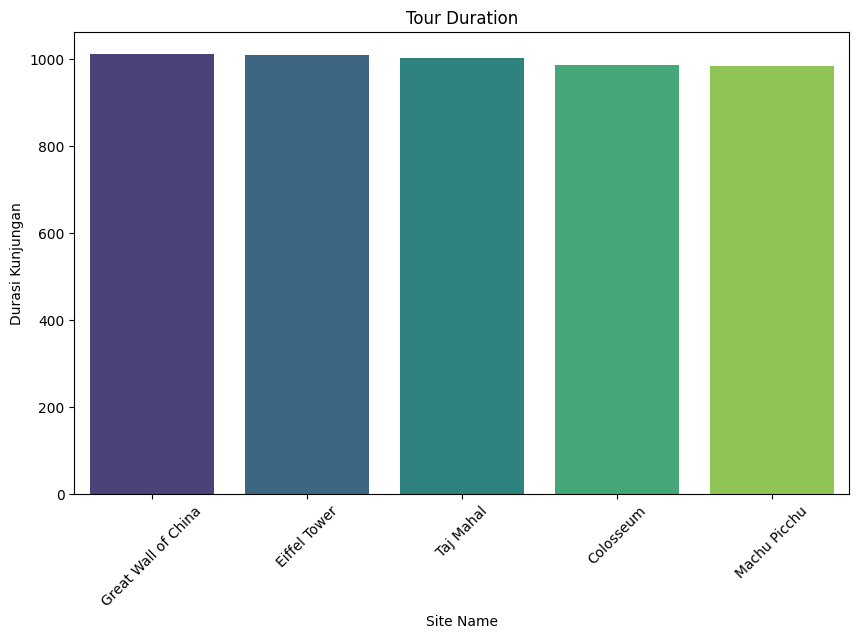

In [ ]:
penjualan_market = df.groupby('Site Name')['Tour Duration'].count().sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=penjualan_market.index, y=penjualan_market.values, palette='viridis', hue=penjualan_market.index, legend=False)
plt.title('Tour Duration')
plt.xlabel('Site Name')
plt.ylabel('Durasi Kunjungan')
plt.xticks(rotation=45)
plt.show()

Insight:

- Jumlah kunjungan pada setiap destinasi relatif merata (sekitar ±1000 data per lokasi).

- Tidak ada destinasi yang sangat dominan atau sangat rendah.

- Dataset tergolong seimbang sehingga perbandingan antar lokasi cukup adil untuk analisis lanjutan.

## **Composition/Komposisi**

Aktivitas: Menganalisis komposisi 3 kategori Interests teratas berdasarkan total Tour Duration.

Tujuan: Mengetahui kategori minat wisatawan mana yang paling dominan serta melihat proporsi kontribusi masing-masing kategori terhadap total durasi kunjungan.

Visualisasi: Pie chart (diagram lingkaran).

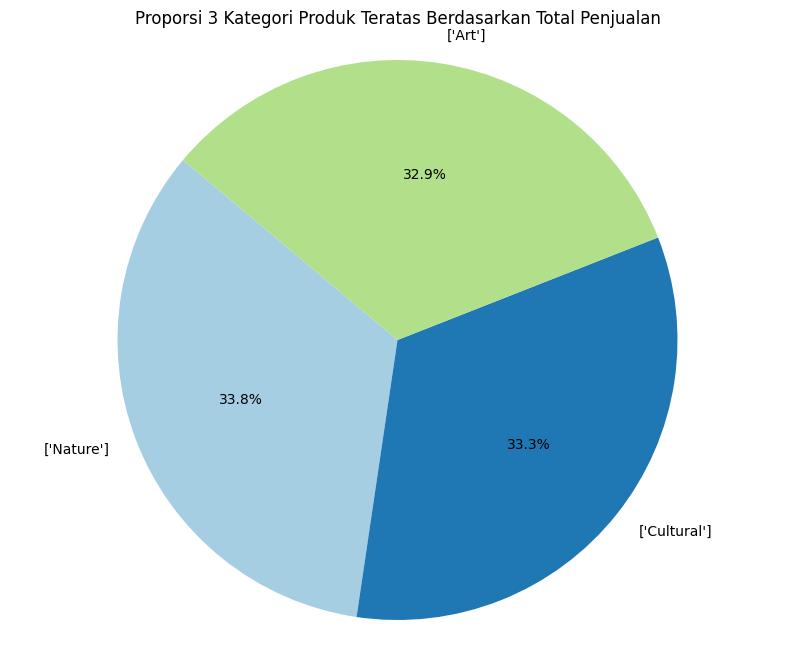

In [ ]:
sales_by_category = df.groupby('Interests')['Tour Duration'].sum().sort_values(ascending=False)
sales_by_category_top3 = sales_by_category.head(3)

plt.figure(figsize=(10, 8))
sales_by_category_top3.plot(kind='pie', autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)
plt.title('Proporsi 3 Kategori Produk Teratas Berdasarkan Total Penjualan')
plt.ylabel('')
plt.axis('equal')
plt.show()

Insight:

- Tiga kategori teratas (Nature, Cultural, Art) memiliki proporsi yang hampir sama (sekitar 33% masing-masing).

- Tidak ada satu kategori yang mendominasi secara signifikan.

- Minat wisatawan terhadap jenis wisata cenderung beragam dan seimbang.

## **Distribution/Distribusi**

Aktivitas: Menganalisis distribusi nilai pada kolom Tour Duration untuk melihat pola durasi kunjungan wisatawan.

Tujuan: Mengetahui rentang durasi yang paling sering dipilih wisatawan secara keseluruhan.

Visualisasi: Histogram dengan KDE (Kernel Density Estimation).

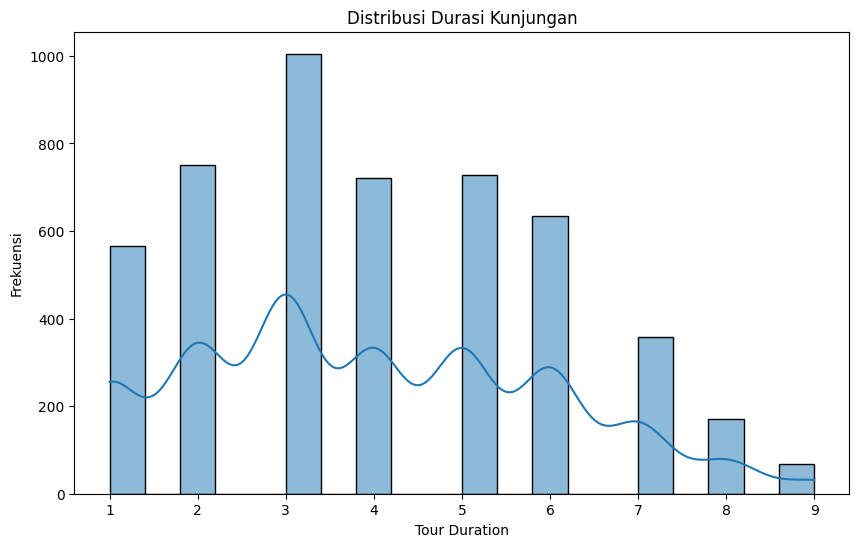

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Tour Duration'], bins=20, kde=True)
plt.title('Distribusi Durasi Kunjungan')
plt.xlabel('Tour Duration')
plt.ylabel('Frekuensi')
plt.show()

Insight:

- Durasi kunjungan paling banyak berada di rentang tengah (sekitar 3–5).

- Durasi sangat tinggi (7–9) memiliki frekuensi lebih rendah.

- Distribusi cenderung sedikit menurun ke kanan (right-skewed ringan), artinya lebih banyak wisatawan memilih durasi sedang dibanding sangat lama.

## **Relationship/Hubungan**

Aktivitas: Menganalisis korelasi antara Tour Duration dengan Umur(Age)

Tujuan: Mengetahui apakah umur wisatawan dapat memengaruhi lamanya durasi kunjungan wisatawan pada tempat wisata

Visualisasi: Heatmap

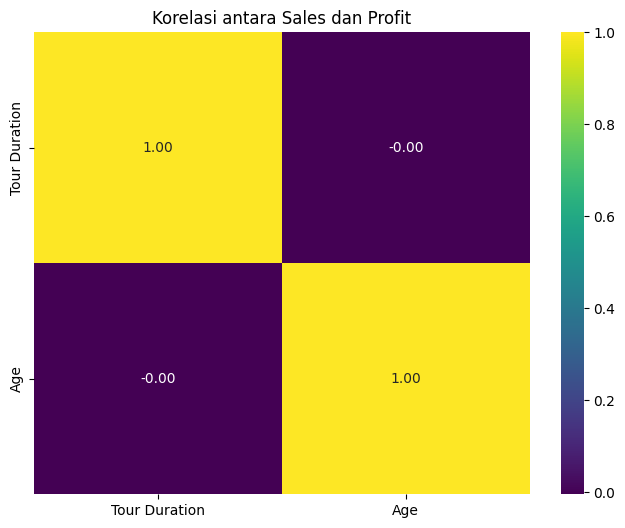

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(data=df[['Tour Duration', 'Age']].corr(),
            annot=True,
            cmap='viridis',
            fmt='.2f')
plt.title('Korelasi antara Sales dan Profit')
plt.show()

# **Data Praporation**

# **Mengecek Tipe Data**

In [ ]:
df.dtypes

,0
Tourist ID,int64
Age,int64
Interests,object
Preferred Tour Duration,int64
Accessibility,bool
Site Name,object
Sites Visited,object
Tour Duration,int64
Route ID,int64
Tourist Rating,float64


dari data diatas seluruh kolom sudah memiliki tipe data yang sesuai dengan jenis datanya, sehingga tidak perlu dilakukan konversi tipe data.

# **Mengidentifikasi Inconsistent Values**

In [ ]:
print(df['Tourist ID'].unique())

[   1    2    3 ... 4998 4999 5000]


In [ ]:
print(df['Age'].unique())

[48 37 43 46 53 50 61 23 34 27 45 60 59 18 24 63 62 65 26 20 36 49 54 29
 44 35 33 47 68 39 56 67 31 55 41 30 22 69 70 25 28 32 19 42 58 52 51 57
 66 40 38 21 64]


In [ ]:
print(df['Interests'].unique())

["['Architecture', 'Art', 'History']" "['Cultural', 'Nature']"
 "['History', 'Art', 'Architecture']"
 "['Cultural', 'Art', 'Architecture']" "['Architecture', 'Art']"
 "['Architecture', 'History', 'Cultural']" "['Architecture', 'History']"
 "['Cultural', 'Architecture']" "['Cultural', 'Art']"
 "['Nature', 'Architecture']" "['Cultural']"
 "['Nature', 'Cultural', 'Architecture']"
 "['Cultural', 'Architecture', 'Art']" "['Nature', 'Cultural']"
 "['History']" "['Architecture']" "['Nature', 'History', 'Cultural']"
 "['Nature', 'Art']" "['Nature', 'Art', 'Cultural']" "['Nature']"
 "['Nature', 'History', 'Architecture']" "['Art', 'Nature']" "['Art']"
 "['Art', 'Cultural']" "['History', 'Nature']"
 "['Architecture', 'Nature']" "['Cultural', 'Nature', 'Art']"
 "['Art', 'Architecture']" "['Art', 'Cultural', 'Architecture']"
 "['History', 'Art', 'Nature']" "['History', 'Art', 'Cultural']"
 "['Art', 'Architecture', 'Nature']" "['History', 'Cultural']"
 "['Cultural', 'History', 'Art']"
 "['Cultural'

In [ ]:
print(df['Preferred Tour Duration'].unique())

[5 6 8 4 7 3]


In [ ]:
print(df['Accessibility'].unique())

[False  True]


In [ ]:
print(df['Site Name'].unique())

['Eiffel Tower' 'Colosseum' 'Machu Picchu' 'Taj Mahal'
 'Great Wall of China']


In [ ]:
print(df['Sites Visited'].unique())

["['Eiffel Tower', 'Great Wall of China', 'Taj Mahal']"
 "['Great Wall of China']" "['Eiffel Tower']"
 "['Machu Picchu', 'Taj Mahal']"
 "['Machu Picchu', 'Taj Mahal', 'Great Wall of China']"
 "['Great Wall of China', 'Eiffel Tower', 'Colosseum']"
 "['Eiffel Tower', 'Colosseum', 'Taj Mahal']" "['Colosseum']"
 "['Colosseum', 'Taj Mahal', 'Machu Picchu']"
 "['Machu Picchu', 'Colosseum', 'Taj Mahal']"
 "['Colosseum', 'Machu Picchu']"
 "['Machu Picchu', 'Eiffel Tower', 'Great Wall of China']"
 "['Taj Mahal', 'Eiffel Tower']"
 "['Great Wall of China', 'Machu Picchu', 'Colosseum']"
 "['Great Wall of China', 'Machu Picchu']" "['Eiffel Tower', 'Colosseum']"
 "['Colosseum', 'Eiffel Tower', 'Taj Mahal']" "['Taj Mahal']"
 "['Machu Picchu', 'Eiffel Tower', 'Taj Mahal']"
 "['Machu Picchu', 'Great Wall of China']"
 "['Machu Picchu', 'Eiffel Tower']"
 "['Colosseum', 'Eiffel Tower', 'Great Wall of China']"
 "['Taj Mahal', 'Great Wall of China', 'Eiffel Tower']"
 "['Taj Mahal', 'Great Wall of China']" "

In [ ]:
print(df['Tour Duration'].unique())

[7 1 2 5 4 6 8 3 9]


In [ ]:
print(df['Route ID'].unique())

[   1000    2000    3000 ... 4998000 4999000 5000000]


In [ ]:
print(df['Tourist Rating'].unique())

[1.6 2.6 1.7 2.  3.7 2.2 4.1 2.8 4.  3.8 3.2 1.8 4.3 2.9 1.2 2.1 2.7 3.3
 4.2 3.  2.4 1.  4.4 4.8 1.9 1.4 4.9 4.5 3.6 3.4 3.5 4.7 3.1 4.6 3.9 1.5
 5.  2.5 1.3 1.1 2.3]


In [ ]:
print(df['System Response Time'].unique())

[3.73 2.89 2.22 2.34 2.   3.74 4.66 4.84 1.54 3.59 4.48 2.63 3.47 3.48
 2.82 4.44 2.12 3.63 4.79 2.75 2.65 1.97 4.02 3.42 4.09 4.62 1.61 4.57
 2.18 4.94 2.36 4.43 4.77 1.73 2.05 3.6  3.1  3.72 3.28 2.8  4.56 3.65
 3.54 1.79 2.39 2.58 3.09 2.57 1.72 1.92 4.42 3.93 3.88 2.94 4.08 3.05
 4.01 4.12 4.86 4.1  4.23 4.25 2.83 3.71 3.95 2.13 3.5  3.16 3.64 3.02
 1.5  3.18 4.87 4.75 2.67 2.72 4.22 3.78 1.76 1.63 2.4  4.59 1.7  1.96
 2.77 4.5  4.58 2.9  2.6  2.95 1.68 3.84 2.1  3.21 2.54 2.97 4.03 3.68
 2.55 3.8  4.4  3.87 4.04 4.68 1.65 2.06 3.06 3.13 4.45 2.24 3.34 1.88
 4.92 2.61 1.83 2.7  1.71 4.27 4.91 3.12 2.17 4.21 4.15 3.46 4.63 2.02
 3.62 3.14 2.53 2.11 3.43 1.62 3.81 1.95 1.85 2.73 3.27 1.86 4.31 2.26
 4.19 2.2  2.68 2.69 4.17 4.7  3.07 2.78 1.55 3.41 1.84 1.78 2.59 4.96
 3.96 2.33 3.33 3.51 2.85 2.21 3.9  2.56 2.92 1.94 2.25 3.7  4.28 4.8
 4.18 2.74 2.45 2.5  1.58 4.16 3.45 2.15 3.61 1.8  1.9  4.9  3.67 3.26
 2.51 4.35 1.99 4.52 3.38 1.74 2.08 3.56 3.   3.44 2.3  2.01 2.48 4.99
 1.51 4

In [ ]:
print(df['Recommendation Accuracy'].unique())

[ 97  90  94  92  96  99  93  91  95 100  86  88  87  85  89  98]


In [ ]:
print(df['VR Experience Quality'].unique())

[4.5 4.7 4.8 4.9 4.4 4.2 4.6 4.3 4.  5.  4.1]


In [ ]:
print(df['Satisfaction'].unique())

[3 4 5]


Dari hasil analisis saya:
1. Tourist ID : Pada data ini sudah bersih dari Inconsistent Values, karena nilainya berupa angka berurutan dari 1 sampai 5000 dan tidak ada duplikasi atau nilai aneh.

2. Age : Pada data ini sudah bersih dari Inconsistent Values, karena semua angka masih dalam rentang umur manusia yang wajar (sekitar 18–70 tahun) dan Tidak ditemukan nilai negatif, nol, atau umur yang tidak masuk akal, sehingga data ini valid dan konsisten.

3. Interests : Pada data ini secara kategori sudah konsisten karena hanya berisi lima jenis minat yaitu Architecture, Art, History, Cultural, dan Nature dan tidak ada penulisan ganda atau typo.

4. Preferred Tour Duration : Data ini sudah konsisten karena hanya berisi angka 3–8 (durasi dalam jam/hari). Tidak ada nilai negatif atau nol. Nilainya juga masih masuk akal sebagai preferensi durasi wisata.

5. Accessibility : Data ini sudah konsisten karena hanya berisi dua nilai boolean: True dan False. Tidak ada variasi penulisan seperti “Yes/No” atau “1/0”.

6. Site Name : Data ini sudah bersih dari Inconsistent Values karena hanya berisi lima nama destinasi dan tidak ada perbedaan penulisan atau typo. Semua kategori konsisten dan jelas.

7. Sites Visited : Secara kategori sudah konsisten karena hanya berisi kombinasi dari lima destinasi yang sama seperti Site Name.

8. Tour Duration : Data ini konsisten karena berupa angka 1–9 dan masih masuk akal sebagai durasi aktual wisata dan tidak ditemukan nilai negatif atau anomali.

9. Route ID : Data ini konsisten karena berbentuk angka kelipatan 1000 dari 1000 sampai 5.000.000.

10. Tourist Rating : Data ini sudah konsisten karena berbentuk numerik desimal (sekitar 1.0–5.0). Tidak ada nilai di luar rentang rating umum. Formatnya juga seragam (tidak ada string atau simbol lain).

11. System Response Time : Data ini konsisten karena berbentuk numerik desimal dan berada dalam rentang wajar (sekitar 1–5 detik). Tidak ada nilai negatif atau nol, sehingga tidak ditemukan anomali.

12. Recommendation Accuracy : Data ini konsisten karena berbentuk integer dengan rentang 85–100 (%). Semua nilai masih logis sebagai tingkat akurasi sistem dan tidak ditemukan nilai di bawah 0 atau di atas 100.

13. VR Experience Quality : Data ini konsisten karena berbentuk desimal dengan rentang 4.0–5.0. Tidak ada nilai anomali atau di luar skala penilaian.

14. Satisfaction : Data ini sudah konsisten karena hanya berisi angka 3, 4, dan 5. Tidak ada nilai di luar skala. Data ini cocok dijadikan variabel target dalam analisis karena bersifat ordinal dan tidak mengandung anomali.


# **Mengidentifikasi Missing Values**

In [ ]:
pd.DataFrame(df.isna().sum() / len(df) * 100, columns=['Null Ratio in %'])

,Null Ratio in %
Tourist ID,0.0
Age,0.0
Interests,0.0
Preferred Tour Duration,0.0
Accessibility,0.0
Site Name,0.0
Sites Visited,0.0
Tour Duration,0.0
Route ID,0.0
Tourist Rating,0.0


Pada tahap ini, kita melihat seberapa banyak data yang hilang pada seluruh kolom. Berdasarkan hasil pengecekan, terlihat bahwa semua kolom memiliki nilai missing sebesar 0%. Hal ini menunjukkan bahwa dataset sudah lengkap dan tidak memerlukan penanganan khusus seperti penghapusan data atau imputasi nilai.

# **Mengidentifikasi Duplicated Values.**

In [ ]:
df[df.duplicated()]

,Tourist ID,Age,Interests,Preferred Tour Duration,Accessibility,Site Name,Sites Visited,Tour Duration,Route ID,Tourist Rating,System Response Time,Recommendation Accuracy,VR Experience Quality,Satisfaction


Aman dari Duplicated Values karena tidak ada data ganda.

Jika ada, kita bisa menggunakan kode df = df.drop_duplicates() untuk memperbaiki data dari Duplicated Values.

# **Mengidentifikasi Outliers**

In [ ]:
results = []

cols = df.select_dtypes(include=['float64', 'int64'])

for col in cols:
  q1 = df[col].quantile(0.25)
  q3 = df[col].quantile(0.75)
  iqr = q3 - q1
  lower_bound = q1 - 1.5*iqr
  upper_bound = q3 + 1.5*iqr
  outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
  percent_outliers = (len(outliers)/len(df))*100
  results.append({'Kolom': col, 'Persentase Outliers': percent_outliers})

#Dataframe dari list hasil

results_df = pd.DataFrame(results)
results_df.set_index('Kolom', inplace=True)
results_df = results_df.rename_axis(None, axis=0).rename_axis('Kolom', axis=1)

#Tampilkan dataframe

display(results_df)

Kolom,Persentase Outliers
Tourist ID,0.0
Age,0.0
Preferred Tour Duration,0.0
Tour Duration,0.0
Route ID,0.0
Tourist Rating,0.0
System Response Time,0.0
Recommendation Accuracy,0.0
VR Experience Quality,0.0
Satisfaction,0.0


Berdasarkan hasil pengecekan pada tabel persentase pencilan, data ini dinyatakan tidak memiliki outliers karena seluruh variabel menunjukkan angka 0.0.

# **Data Reduction**

In [ ]:
df_reduced = df.drop(columns=['Route ID'])
df_reduced.head()

,Tourist ID,Age,Interests,Preferred Tour Duration,Accessibility,Site Name,Sites Visited,Tour Duration,Tourist Rating,System Response Time,Recommendation Accuracy,VR Experience Quality,Satisfaction
0,1,48,"['Architecture', 'Art', 'History']",5,False,Eiffel Tower,"['Eiffel Tower', 'Great Wall of China', 'Taj M...",7,1.6,3.73,97,4.5,3
1,2,37,"['Cultural', 'Nature']",6,False,Colosseum,['Great Wall of China'],1,2.6,2.89,90,4.5,3
2,3,43,"['History', 'Art', 'Architecture']",6,True,Machu Picchu,['Eiffel Tower'],2,1.7,2.22,94,4.7,3
3,4,46,"['Cultural', 'Art', 'Architecture']",8,False,Colosseum,"['Machu Picchu', 'Taj Mahal']",5,2.0,2.34,92,4.7,3
4,5,53,"['Architecture', 'Art']",5,True,Colosseum,"['Machu Picchu', 'Taj Mahal', 'Great Wall of C...",7,3.7,2.00,96,4.8,4


Kolom Route ID dihapus pada tahap Data Preparation karena hanya berfungsi sebagai identifier unik dan tidak memiliki nilai informatif yang dapat mempengaruhi variabel target. Penggunaan identifier dalam proses modeling dapat menimbulkan bias karena model akan menganggap nilai numerik tersebut memiliki hubungan matematis, padahal tidak merepresentasikan karakteristik rute yang sebenarnya.

# **Construct Data**

In [ ]:
def categorize_lama_durasi(TourDuration):
    if TourDuration > 4:
        return 'Durasi_lama'
    elif TourDuration < 5:
        return 'Durasi_Sebentar'
    else:
        return 'Break Even'

df['kategori_lama_durasi'] = df['Tour Duration'].apply(categorize_lama_durasi)

Disini menambahkan kolom baru yaitu kategori_lama_durasi untuk mendefinisikan secara jelas dari tourduration

In [ ]:
df

,Tourist ID,Age,Interests,Preferred Tour Duration,Accessibility,Site Name,Sites Visited,Tour Duration,Route ID,Tourist Rating,System Response Time,Recommendation Accuracy,VR Experience Quality,Satisfaction,kategori_lama_durasi
0,1,48,"['Architecture', 'Art', 'History']",5,False,Eiffel Tower,"['Eiffel Tower', 'Great Wall of China', 'Taj M...",7,1000,1.6,3.73,97,4.5,3,Durasi_lama
1,2,37,"['Cultural', 'Nature']",6,False,Colosseum,['Great Wall of China'],1,2000,2.6,2.89,90,4.5,3,Durasi_Sebentar
2,3,43,"['History', 'Art', 'Architecture']",6,True,Machu Picchu,['Eiffel Tower'],2,3000,1.7,2.22,94,4.7,3,Durasi_Sebentar
3,4,46,"['Cultural', 'Art', 'Architecture']",8,False,Colosseum,"['Machu Picchu', 'Taj Mahal']",5,4000,2.0,2.34,92,4.7,3,Durasi_lama
4,5,53,"['Architecture', 'Art']",5,True,Colosseum,"['Machu Picchu', 'Taj Mahal', 'Great Wall of C...",7,5000,3.7,2.00,96,4.8,4,Durasi_lama
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,31,"['Architecture', 'History', 'Cultural']",3,False,Great Wall of China,['Great Wall of China'],2,4996000,3.9,2.53,100,4.4,4,Durasi_Sebentar
4996,4997,28,"['Architecture', 'Cultural', 'Nature']",7,True,Great Wall of China,['Colosseum'],1,4997000,4.3,1.53,100,5.0,4,Durasi_Sebentar
4997,4998,42,"['History', 'Cultural', 'Nature']",3,True,Machu Picchu,['Taj Mahal'],1,4998000,3.2,3.99,89,4.4,3,Durasi_Sebentar
4998,4999,58,"['Cultural', 'Art', 'History']",5,False,Colosseum,"['Taj Mahal', 'Great Wall of China', 'Colosseum']",7,4999000,2.5,2.13,98,4.4,3,Durasi_lama


Bisa dilihat diatas kolom kategori_lama_durasi ditambahkan untuk mendefinisikan dari kolom Tourduration apakah rating tersebut durasi_lama atau durasi_sebentar

## **CheckPoint4**

In [ ]:
df.dtypes

,0
Tourist ID,int64
Age,int64
Interests,object
Preferred Tour Duration,int64
Accessibility,bool
Site Name,object
Sites Visited,object
Tour Duration,int64
Route ID,int64
Tourist Rating,float64


# **Bar Chart**

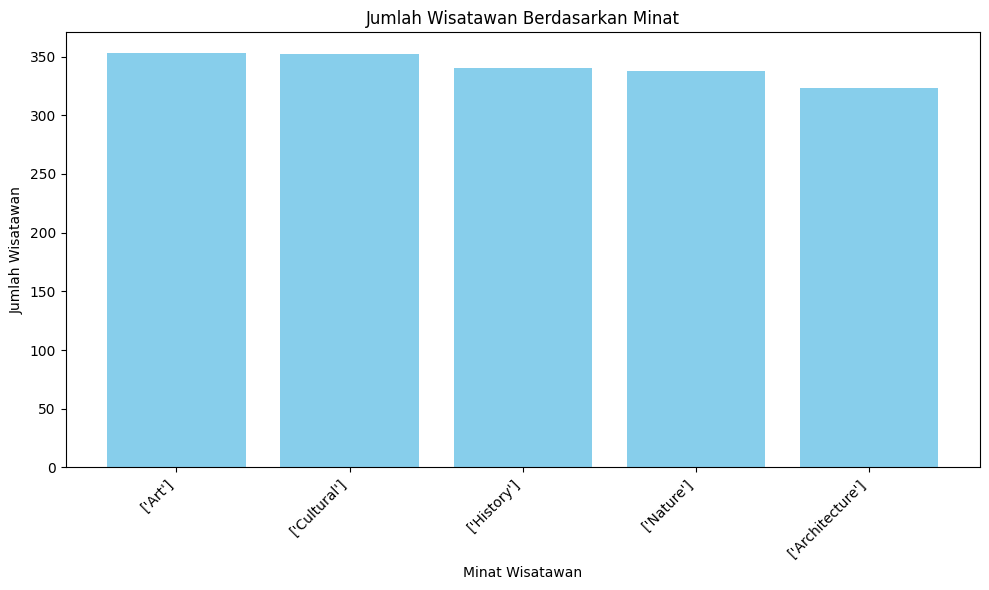

In [ ]:
top_interests = df['Interests'].value_counts().head(5).sort_values(ascending=False) # mengambil 5 minat terbanyak

plt.figure(figsize=(10, 6)) # Ukuran
plt.bar(top_interests.index, top_interests.values, color='skyblue') # warna bar
plt.xlabel('Minat Wisatawan') # keterangan X label
plt.ylabel('Jumlah Wisatawan') # keterangan Y label
plt.title('Jumlah Wisatawan Berdasarkan Minat') # Judul
plt.xticks(rotation=45, ha='right') # rotasi teks
plt.tight_layout()
plt.show()

Insight:

1. Minat wisata Art dan Cultural terlihat paling banyak diminati wisatawan dibanding kategori lainnya. Jumlahnya hampir sama dan berada di posisi teratas, yang berarti wisata yang berkaitan dengan seni dan budaya cukup populer bagi pengunjung.

2. Minat History dan Nature juga memiliki jumlah yang cukup tinggi, meskipun sedikit di bawah Art dan Cultural. Ini menunjukkan bahwa wisata sejarah dan alam juga masih menjadi pilihan favorit wisatawan, hanya saja tingkat ketertarikannya sedikit lebih rendah.

3. Minat Architecture memiliki jumlah wisatawan paling sedikit dibandingkan kategori lain pada grafik ini. Artinya wisata yang berfokus pada arsitektur tidak sepopuler kategori lainnya dalam dataset ini.

4. Secara keseluruhan, perbedaan jumlah antar kategori sebenarnya tidak terlalu jauh, yang berarti minat wisatawan cukup beragam dan tidak hanya terfokus pada satu jenis wisata saja.

Action:

1. Fokuskan promosi pada wisata seni dan budaya (Art dan Cultural) karena kategori ini memiliki minat wisatawan paling tinggi. Paket tur, rekomendasi destinasi, atau konten promosi bisa lebih banyak menampilkan jenis wisata ini.

2. Kembangkan pengalaman wisata pada kategori History dan Nature karena peminatnya juga cukup besar. Misalnya dengan menambah informasi sejarah, aktivitas alam, atau rute wisata yang lebih menarik.

3. Untuk kategori Architecture, bisa dilakukan peningkatan daya tarik, misalnya dengan membuat paket tur khusus arsitektur, menambahkan storytelling tentang bangunan bersejarah, atau menggabungkannya dengan wisata budaya agar lebih menarik bagi wisatawan.

4. Karena minat wisatawan cukup beragam, sistem rekomendasi wisata juga sebaiknya tetap memberikan pilihan destinasi yang bervariasi, sehingga pengguna dengan minat berbeda tetap mendapatkan rekomendasi yang sesuai.

# **Pie Chart**

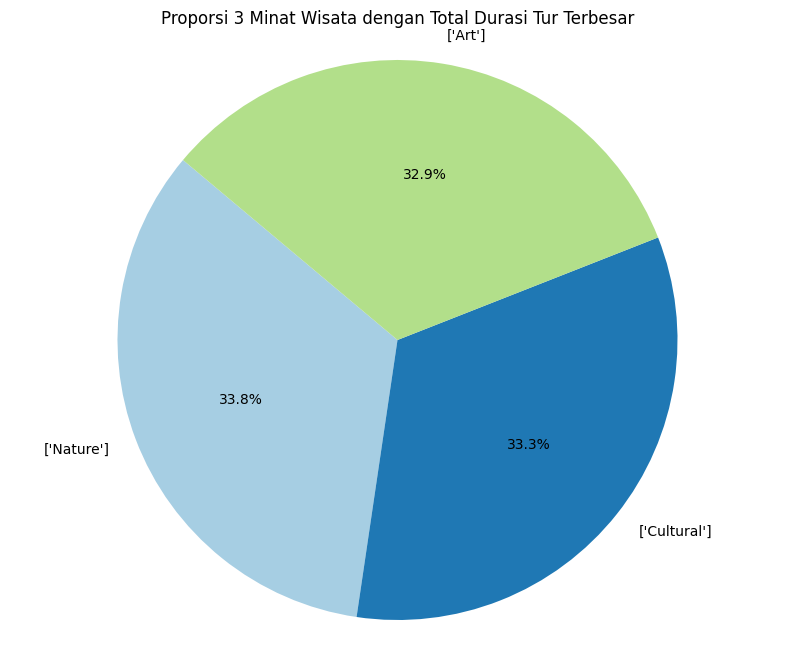

In [ ]:
durasi_minat = df.groupby('Interests')['Tour Duration'].sum().sort_values(ascending=False)
durasi_minat_top3 = durasi_minat.head(3)

plt.figure(figsize=(10, 8)) # Ukuran
durasi_minat_top3.plot(kind='pie', autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)

plt.title('Proporsi 3 Minat Wisata dengan Total Durasi Tur Terbesar') # Judul
plt.ylabel('')
plt.axis('equal')
plt.show()

Insight:

1. Minat wisata Nature memiliki proporsi durasi tur paling besar yaitu sekitar 33.8%. Ini menunjukkan bahwa wisatawan yang tertarik dengan wisata alam cenderung menghabiskan waktu tur lebih lama dibandingkan kategori lainnya.

2. Minat Cultural berada di posisi kedua dengan proporsi sekitar 33.3%. Artinya wisata budaya juga membuat wisatawan menghabiskan waktu yang cukup lama selama perjalanan tur.

3. Minat Art memiliki proporsi sekitar 32.9%, sedikit lebih rendah dibanding dua kategori lainnya. Meskipun demikian, perbedaannya tidak terlalu jauh sehingga dapat disimpulkan bahwa ketiga jenis wisata ini memiliki daya tarik yang hampir seimbang terhadap durasi kunjungan wisatawan.

4. Secara keseluruhan, grafik ini menunjukkan bahwa wisata alam, budaya, dan seni sama-sama membuat wisatawan menghabiskan waktu yang cukup lama dalam tur, sehingga ketiga kategori tersebut menjadi minat utama dalam aktivitas wisata.

Action:

1. Perkuat pengembangan paket wisata Nature karena wisatawan cenderung menghabiskan durasi tur paling lama pada kategori ini. Misalnya dengan menambah aktivitas outdoor, jalur trekking, atau pengalaman alam lainnya.

2. Optimalkan pengalaman pada wisata Cultural, seperti menambahkan pemandu wisata, storytelling sejarah, atau kegiatan budaya lokal agar wisatawan semakin tertarik untuk menjelajahi destinasi lebih lama.

3. Tingkatkan daya tarik wisata Art dengan menambahkan event seni, pameran, atau aktivitas interaktif sehingga wisatawan bisa memiliki pengalaman yang lebih menarik selama tur.

4. Karena ketiga kategori memiliki proporsi yang hampir sama, sistem rekomendasi wisata juga sebaiknya memberikan pilihan yang seimbang antara wisata alam, budaya, dan seni agar dapat memenuhi berbagai preferensi wisatawan.

# **Line Chart**

Untuk Line Chart nya gak ada karna dari dataset saya tidak ada berdasarkan bulan, tahun dan tanggal jadii tidak bisa menggunakan grafik Line Chart

# **Histogram**

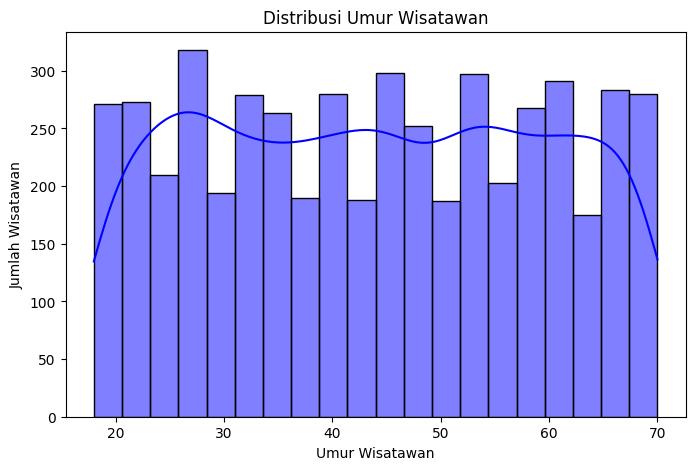

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Age'], bins=20, kde=True, color='blue')

plt.title('Distribusi Umur Wisatawan')
plt.xlabel('Umur Wisatawan')
plt.ylabel('Jumlah Wisatawan')

plt.show()

Insight:

1. Distribusi umur wisatawan terlihat cukup menyebar dari sekitar 18 hingga 70 tahun, yang berarti dataset ini mencakup berbagai kelompok usia, mulai dari usia muda hingga usia yang lebih tua.

2. Jumlah wisatawan pada setiap rentang umur terlihat relatif merata, tidak ada satu kelompok usia yang sangat dominan. Namun, terlihat bahwa wisatawan pada rentang usia sekitar 25–60 tahun memiliki jumlah yang cukup konsisten dan sedikit lebih tinggi dibandingkan usia yang sangat muda atau sangat tua.

3. Hal ini menunjukkan bahwa wisata berbasis sistem rekomendasi dalam dataset ini digunakan oleh berbagai kelompok umur, tetapi sebagian besar pengguna berada pada usia produktif atau usia dewasa.

Action:

1. Karena mayoritas wisatawan berada pada usia dewasa (sekitar 25–60 tahun), pengembangan sistem rekomendasi wisata bisa lebih difokuskan pada kebutuhan kelompok usia tersebut, seperti wisata budaya, alam, atau pengalaman yang lebih eksploratif.

2. Tetap sediakan opsi wisata yang ramah untuk berbagai usia, karena dataset menunjukkan bahwa pengguna sistem tidak hanya berasal dari satu kelompok umur saja.

3. Untuk wisatawan usia yang lebih muda, bisa ditambahkan rekomendasi wisata yang lebih interaktif atau berbasis pengalaman, seperti aktivitas petualangan atau kegiatan outdoor.

4. Sedangkan untuk wisatawan usia yang lebih tua, sistem dapat memberikan rekomendasi wisata yang lebih santai dan mudah diakses, seperti wisata budaya, sejarah, atau tempat wisata dengan fasilitas yang nyaman.

# **Box PLot**

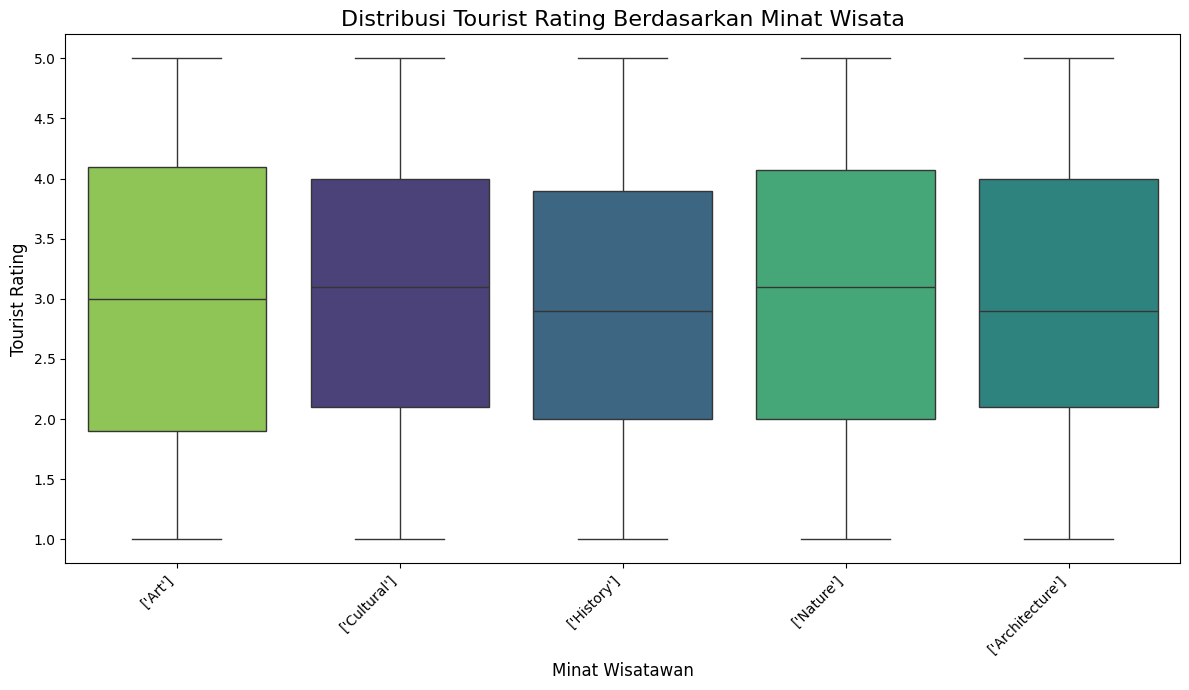

In [ ]:
top_interests = df['Interests'].value_counts().head(5).index
filtered_data = df[df['Interests'].isin(top_interests)]

plt.figure(figsize=(12, 7)) # Ukuran figure
sns.boxplot(x='Interests', y='Tourist Rating', data=filtered_data, palette='viridis', order=top_interests, hue='Interests', legend=False)

plt.title('Distribusi Tourist Rating Berdasarkan Minat Wisata', fontsize=16) # Judul
plt.xlabel('Minat Wisatawan', fontsize=12) # X Keterangan
plt.ylabel('Tourist Rating', fontsize=12) # Y Keterangan

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Insight:

1. Rating wisatawan pada setiap kategori minat wisata relatif mirip tanpa perbedaan yang signifikan. Median rating berada di sekitar nilai 3, yang menunjukkan sebagian besar wisatawan memberikan penilaian cukup terhadap pengalaman wisata mereka.

2. Minat wisata Nature dan Cultural memiliki median rating sedikit lebih tinggi dibanding kategori lainnya, yang menunjukkan wisata alam dan budaya cenderung memberikan pengalaman yang lebih memuaskan bagi wisatawan.

3. Minat Art, History, dan Architecture memiliki distribusi rating yang cukup luas, dari rendah hingga tinggi. Ini menunjukkan pengalaman wisata pada kategori tersebut cukup bervariasi tergantung destinasi dan pengalaman wisatawan.

4. Secara keseluruhan, variasi rating menunjukkan bahwa kepuasan wisatawan tidak hanya dipengaruhi oleh jenis minat wisata, tetapi juga oleh faktor lain seperti kualitas layanan, pengalaman tur, dan sistem rekomendasi.

Action:

1. Tingkatkan kualitas pengalaman pada wisata Art, History, dan Architecture dengan memperbaiki informasi wisata, fasilitas, serta menambahkan pengalaman yang lebih interaktif bagi wisatawan.

2. Pertahankan dan terus kembangkan wisata Nature dan Cultural karena kategori ini menunjukkan kecenderungan rating yang sedikit lebih tinggi dari wisatawan.

3. Gunakan data rating wisatawan sebagai bahan evaluasi untuk mengetahui destinasi atau aktivitas wisata mana yang perlu diperbaiki agar pengalaman wisata menjadi lebih konsisten.

4. Pengembangan sistem rekomendasi perlu mempertimbangkan faktor lain seperti kualitas pengalaman wisata, akurasi rekomendasi, dan kepuasan wisatawan agar dapat meningkatkan rating dari pengguna.

# **ScatterPlot**

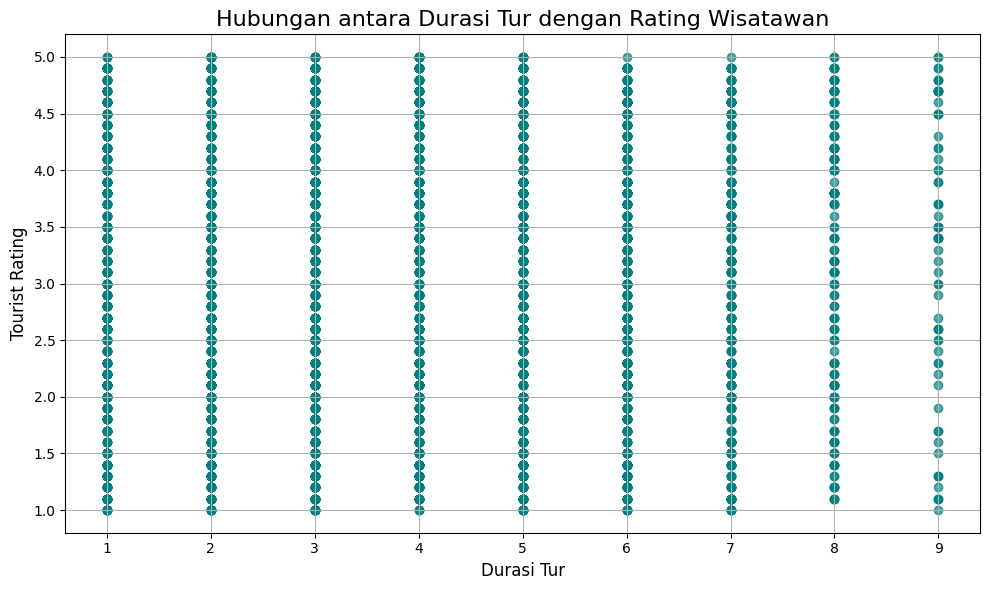

In [ ]:
plt.figure(figsize=(10, 6)) # Ukuran
plt.scatter(df['Tour Duration'], df['Tourist Rating'], alpha=0.7, color='teal') # Warna

plt.title('Hubungan antara Durasi Tur dengan Rating Wisatawan', fontsize=16) # Judul
plt.xlabel('Durasi Tur', fontsize=12) # X Keterangan
plt.ylabel('Tourist Rating', fontsize=12) # Y Keterangan

plt.grid(True)
plt.tight_layout()
plt.show()

Insight:

1. Durasi tur tidak memiliki hubungan yang kuat dengan rating wisatawan. Pada hampir semua durasi, rating tersebar dari rendah hingga tinggi, sehingga lama tur tidak selalu menentukan kepuasan wisatawan.

2. Sebagian besar rating terlihat berkumpul di sekitar nilai 3 sampai 4, yang berarti banyak wisatawan merasa pengalaman tur mereka cukup baik, terlepas dari durasi tur yang mereka jalani.

3. Pada durasi tur yang lebih panjang (7–9), rating wisatawan tetap bervariasi. Ini menunjukkan bahwa menambah durasi tur tidak otomatis meningkatkan kepuasan, karena kemungkinan faktor lain seperti kualitas destinasi dan pengalaman tur lebih berpengaruh.
4. Secara keseluruhan, durasi tur bukan faktor utama yang menentukan kepuasan wisatawan, karena rating tinggi maupun rendah bisa muncul pada semua durasi tur.

Action:

1. Fokus pada peningkatan kualitas pengalaman tur, seperti kualitas destinasi wisata, aktivitas selama tur, dan kenyamanan wisatawan, karena hal tersebut kemungkinan lebih berpengaruh terhadap rating dibandingkan hanya menambah durasi tur.

2. Buat itinerary tur yang lebih menarik dan efisien, sehingga meskipun durasi tur tidak terlalu lama, wisatawan tetap mendapatkan pengalaman yang memuaskan.

3. Gunakan data rating untuk mengidentifikasi destinasi atau rute tur yang sering mendapatkan rating rendah, sehingga bisa dilakukan evaluasi dan perbaikan.

4. Selain durasi, sistem rekomendasi wisata juga bisa mempertimbangkan faktor lain seperti minat wisatawan, kualitas pengalaman VR, atau tingkat kepuasan sebelumnya agar rekomendasi tur menjadi lebih relevan dan meningkatkan rating dari wisatawan.

# **Heatmap**

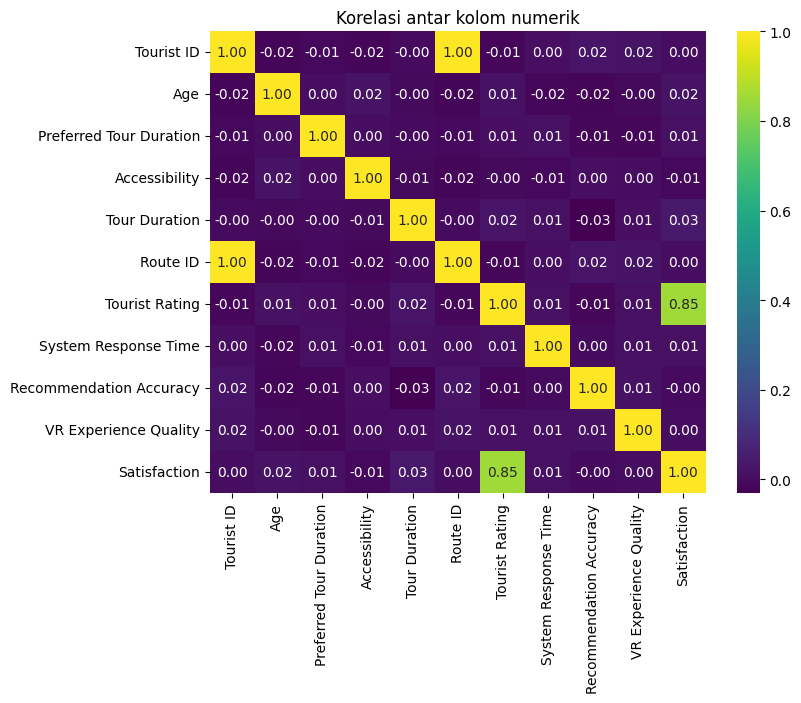

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(data=df.corr(numeric_only=True),
            annot=True,
            cmap='viridis',
            fmt='.2f')
plt.title('Korelasi antar kolom numerik')
plt.show()

Insight:

1. Tourist Rating dan Satisfaction memiliki hubungan yang sangat kuat (0.85). Artinya semakin tinggi rating yang diberikan wisatawan, biasanya tingkat kepuasan mereka juga ikut meningkat.

2. variabel lain seperti Age, Preferred Tour Duration, Tour Duration, System Response Time, Recommendation Accuracy, dan VR Experience Quality memiliki korelasi yang sangat kecil. Ini menunjukkan bahwa hubungan antar variabel tersebut relatif lemah atau tidak terlalu berpengaruh langsung.

3. Selain itu, Tour Duration juga tidak memiliki hubungan yang signifikan dengan Tourist Rating maupun Satisfaction. Hal ini menandakan bahwa lama tur bukan faktor utama yang menentukan kepuasan wisatawan.

4. Secara umum, heatmap ini menunjukkan bahwa kepuasan wisatawan lebih dipengaruhi oleh pengalaman yang mereka rasakan secara keseluruhan, yang tercermin dari rating yang mereka berikan, dibandingkan oleh faktor demografis atau teknis lainnya.

Action:

1. Fokus meningkatkan kualitas pengalaman wisata, karena rating wisatawan sangat berkaitan dengan tingkat kepuasan mereka. Hal ini bisa dilakukan dengan meningkatkan kualitas destinasi, aktivitas tur, serta pelayanan selama tur berlangsung.

2. Gunakan Tourist Rating sebagai indikator utama evaluasi layanan, karena rating terbukti sangat berkorelasi dengan kepuasan wisatawan.

3. Evaluasi fitur sistem seperti VR Experience Quality dan Recommendation Accuracy untuk melihat apakah masih bisa ditingkatkan, karena saat ini pengaruhnya terhadap kepuasan masih terlihat kecil.

4. Daripada hanya menambah durasi tur, lebih baik fokus pada kualitas itinerary dan pengalaman wisata agar wisatawan merasa lebih puas dan memberikan rating yang lebih tinggi.

# **Menyimpan Dataset**

In [ ]:
df.to_csv('Check_Point3 IslamiPasya_108', index=False)